# đọc file data


In [1]:
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

DATA_BASENAME = "hotel_bookings"
VERSION_PATTERN = re.compile(rf"^{DATA_BASENAME}_v(\d+)\.csv$", re.IGNORECASE)


def _data_search_roots() -> list[Path]:
    """Các thư mục ưu tiên tìm file data."""
    notebook_dir = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
    search_roots = [
        notebook_dir / "data",
        notebook_dir,
        notebook_dir.parent / "data",
        notebook_dir.parent,
        notebook_dir.parent.parent,
        Path.cwd() / "data",
        Path.cwd(),
    ]

    path = Path.cwd()
    for _ in range(6):
        search_roots.extend([path / "data", path])
        path = path.parent

    seen, roots = set(), []
    for root in search_roots:
        try:
            root = root.resolve()
        except OSError:
            continue
        if root not in seen:
            seen.add(root)
            roots.append(root)
    return roots


def find_latest_versioned_data_file() -> Path:
    """Tìm file hotel_bookings_v{n}.csv mới nhất, bỏ qua file *test*."""
    candidates: list[tuple[int, Path]] = []

    for root in _data_search_roots():
        if not root.is_dir():
            continue
        for file_path in root.glob(f"{DATA_BASENAME}_v*.csv"):
            name = file_path.name
            if "test" in name.lower():
                continue
            match = VERSION_PATTERN.match(name)
            if match:
                candidates.append((int(match.group(1)), file_path.resolve()))

    if not candidates:
        checked = [str(r / f"{DATA_BASENAME}_v*.csv") for r in _data_search_roots()[:8]]
        raise FileNotFoundError(
            f"Không tìm thấy file '{DATA_BASENAME}_v*.csv' (loại trừ *test*).\n"
            f"Thư mục làm việc: {Path.cwd()}\n"
            f"Đã quét:\n  - " + "\n  - ".join(checked)
        )

    latest_version, latest_path = max(candidates, key=lambda item: item[0])
    print(f"Chọn file v{latest_version} mới nhất: {latest_path.name}")
    return latest_path


csv_path = find_latest_versioned_data_file()
print(f"Đang đọc: {csv_path}")
df = pd.read_csv(
    csv_path,
    usecols=[
        "lead_time",
        "is_canceled",
        "deposit_type",
        "market_segment",
        "distribution_channel",
    ],
)
print(f"Số booking: {len(df):,}")

Chọn file v5 mới nhất: hotel_bookings_v5.csv
Đang đọc: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv
Số booking: 82,811


## Phân tích Cancellation theo ``lead_time``

In [2]:
# Bin lead_time theo khoảng yêu cầu
BIN_LABELS = ["0-30", "31-60", "61-90", "91-180", ">180"]
BIN_EDGES = [0, 30, 60, 90, 180, df["lead_time"].max() + 1]

df["lead_time_bin"] = pd.cut(
    df["lead_time"],
    bins=BIN_EDGES,
    labels=BIN_LABELS,
    right=True,
    include_lowest=True,
)

df["cancel_status"] = df["is_canceled"].map({0: "Không hủy (0)", 1: "Đã hủy (1)"})

# Bảng đếm: số booking theo bin và trạng thái hủy
count_table = (
    df.groupby(["lead_time_bin", "cancel_status"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(BIN_LABELS)
)

print("=== Số lượng booking theo lead_time bin ===")
display(count_table)

# Tỷ lệ hủy theo từng bin
cancel_rate = (
    df.groupby("lead_time_bin", observed=True)["is_canceled"]
    .agg(bookings="count", canceled="sum", cancel_rate_pct=lambda x: x.mean() * 100)
    .reindex(BIN_LABELS)
)
print("\n=== Tỷ lệ hủy (%) theo lead_time bin ===")
display(cancel_rate.round(2))

=== Số lượng booking theo lead_time bin ===


cancel_status,Không hủy (0),Đã hủy (1)
lead_time_bin,,
0-30,27480,5559
31-60,8661,4115
61-90,5989,2978
91-180,11177,6178
>180,6220,4454



=== Tỷ lệ hủy (%) theo lead_time bin ===


,bookings,canceled,cancel_rate_pct
lead_time_bin,,,
0-30,33039,5559,16.83
31-60,12776,4115,32.21
61-90,8967,2978,33.21
91-180,17355,6178,35.60
>180,10674,4454,41.73


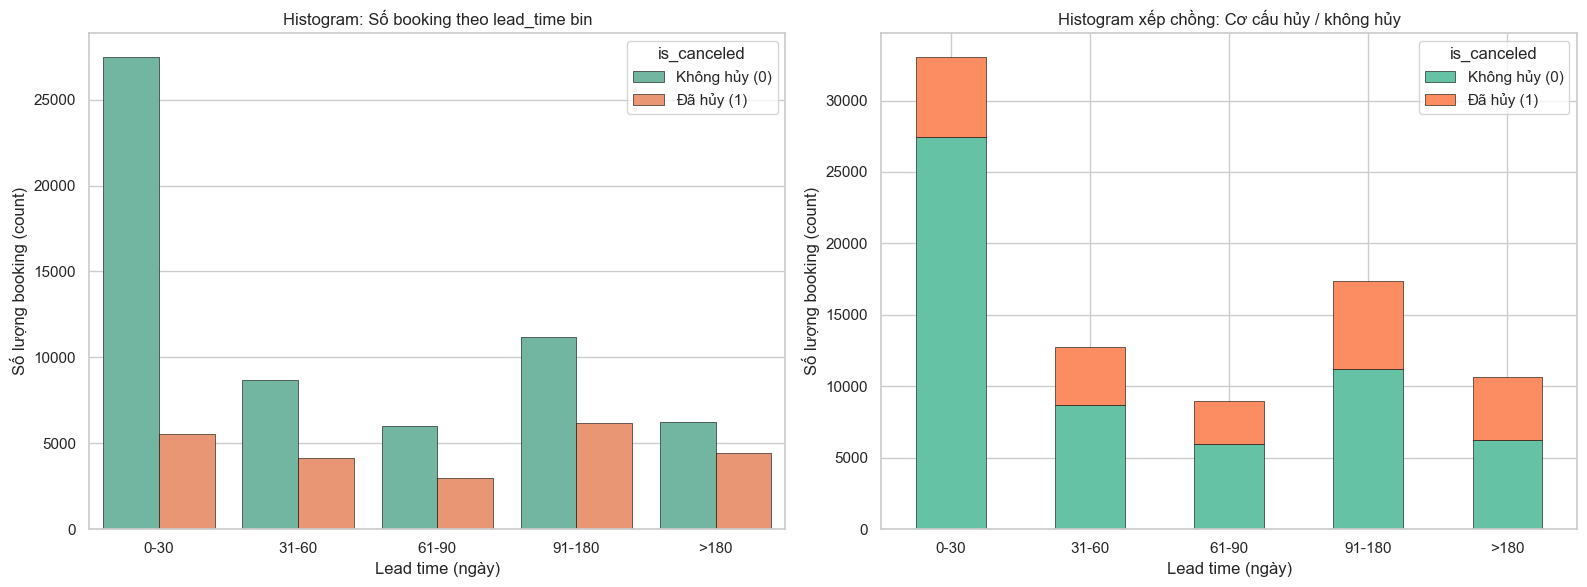

In [3]:
# --- Biểu đồ 1: Histogram (count) theo bin, tách theo is_canceled ---
plot_df = (
    df.groupby(["lead_time_bin", "cancel_status"], observed=True)
    .size()
    .reset_index(name="count")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar chart
sns.barplot(
    data=plot_df,
    x="lead_time_bin",
    y="count",
    hue="cancel_status",
    order=BIN_LABELS,
    ax=axes[0],
    edgecolor="black",
    linewidth=0.4,
)
axes[0].set_title("Histogram: Số booking theo lead_time bin")
axes[0].set_xlabel("Lead time (ngày)")
axes[0].set_ylabel("Số lượng booking (count)")
axes[0].legend(title="is_canceled", loc="upper right")

# Stacked bar (tổng quan tỷ trọng)
count_table.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=["#66c2a5", "#fc8d62"],
    edgecolor="black",
    linewidth=0.4,
)
axes[1].set_title("Histogram xếp chồng: Cơ cấu hủy / không hủy")
axes[1].set_xlabel("Lead time (ngày)")
axes[1].set_ylabel("Số lượng booking (count)")
axes[1].legend(title="is_canceled")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

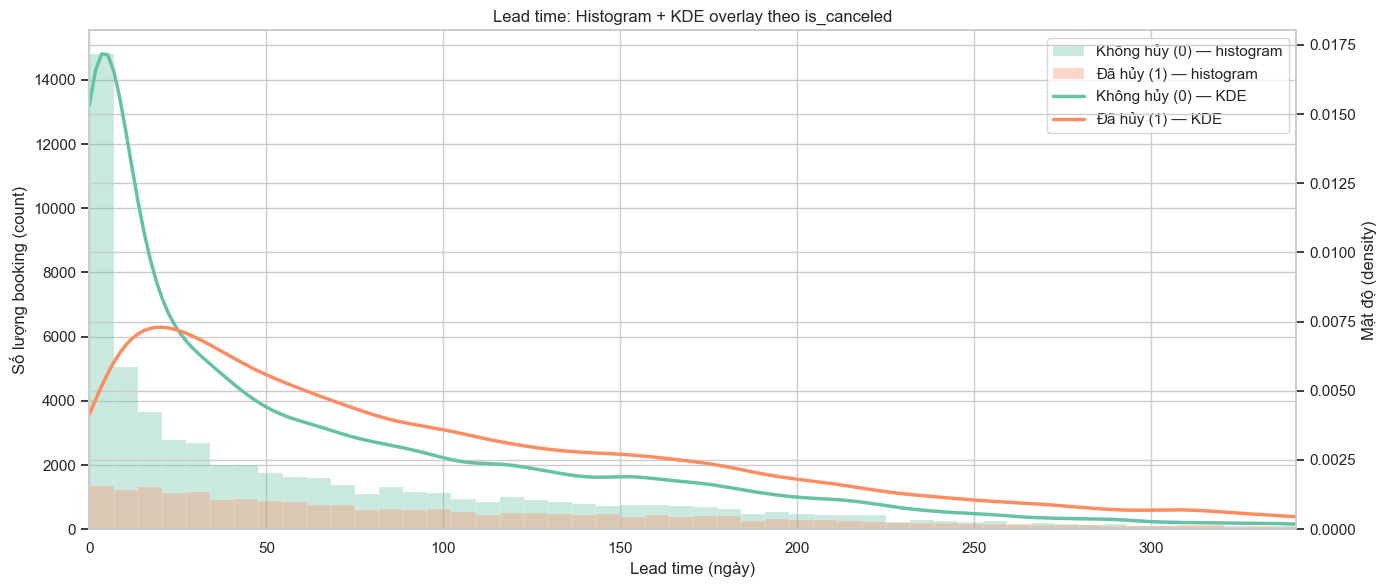

In [4]:
# --- Biểu đồ 2: Histogram (count) + KDE (density) — trục Y kép ---
# Histogram dùng count (~ hàng nghìn), KDE dùng density (~ 0.01) → cần 2 trục Y
fig, ax_hist = plt.subplots(figsize=(14, 6))
ax_kde = ax_hist.twinx()

colors = {0: "#66c2a5", 1: "#fc8d62"}
labels = {0: "Không hủy (0)", 1: "Đã hủy (1)"}
xlim_max = min(365, df["lead_time"].quantile(0.99))

for status in [0, 1]:
    subset = df.loc[df["is_canceled"] == status, "lead_time"]

    ax_hist.hist(
        subset,
        bins=50,
        range=(0, xlim_max),
        alpha=0.35,
        color=colors[status],
        label=f"{labels[status]} — histogram",
        edgecolor="white",
        linewidth=0.3,
    )

    sns.kdeplot(
        subset,
        ax=ax_kde,
        color=colors[status],
        linewidth=2.5,
        bw_adjust=0.8,
        clip=(0, xlim_max),
        label=f"{labels[status]} — KDE",
        common_norm=False,
    )

ax_hist.set_xlim(0, xlim_max)
ax_hist.set_xlabel("Lead time (ngày)")
ax_hist.set_ylabel("Số lượng booking (count)")
ax_kde.set_ylabel("Mật độ (density)")
ax_hist.set_title("Lead time: Histogram + KDE overlay theo is_canceled")

# Gộp legend từ 2 trục
lines_hist, labels_hist = ax_hist.get_legend_handles_labels()
lines_kde, labels_kde = ax_kde.get_legend_handles_labels()
ax_hist.legend(lines_hist + lines_kde, labels_hist + labels_kde, loc="upper right")

plt.tight_layout()
plt.show()

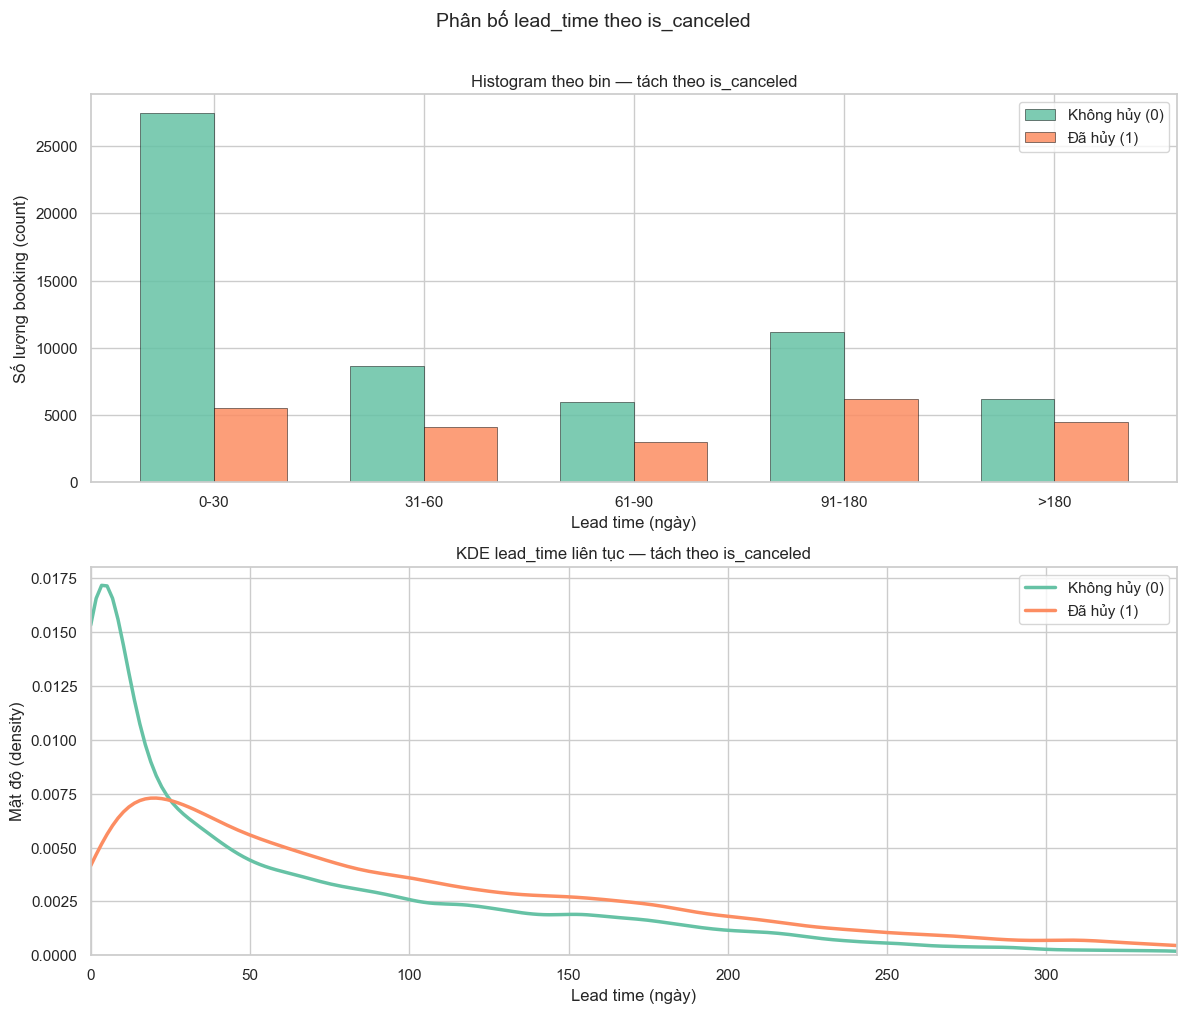

In [5]:
# --- Biểu đồ 3: Tách 2 subplot (histogram bin + KDE liên tục) ---
status_labels = {0: "Không hủy (0)", 1: "Đã hủy (1)"}
colors = {0: "#66c2a5", 1: "#fc8d62"}

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)
x_pos = np.arange(len(BIN_LABELS))
bar_width = 0.35

# Subplot 1: Histogram theo bin (trục X = nhóm lead_time)
ax_hist = axes[0]
for status, offset in [(0, -bar_width / 2), (1, bar_width / 2)]:
    col_name = status_labels[status]
    ax_hist.bar(
        x_pos + offset,
        count_table[col_name].values,
        width=bar_width,
        color=colors[status],
        alpha=0.85,
        label=col_name,
        edgecolor="black",
        linewidth=0.4,
    )

ax_hist.set_xticks(x_pos)
ax_hist.set_xticklabels(BIN_LABELS)
ax_hist.set_xlabel("Lead time (ngày)")
ax_hist.set_ylabel("Số lượng booking (count)")
ax_hist.set_title("Histogram theo bin — tách theo is_canceled")
ax_hist.legend(loc="upper right")

# Subplot 2: KDE trên lead_time liên tục (trục X = số ngày)
ax_kde = axes[1]
kde_xlim = min(365, df["lead_time"].quantile(0.99))  # giới hạn vùng có dữ liệu chính

for status in [0, 1]:
    subset = df.loc[df["is_canceled"] == status, "lead_time"]
    sns.kdeplot(
        subset,
        ax=ax_kde,
        color=colors[status],
        linewidth=2.5,
        bw_adjust=0.8,
        label=status_labels[status],
        clip=(0, kde_xlim),
        common_norm=False,
    )

ax_kde.set_xlim(0, kde_xlim)
ax_kde.set_xlabel("Lead time (ngày)")
ax_kde.set_ylabel("Mật độ (density)")
ax_kde.set_title("KDE lead_time liên tục — tách theo is_canceled")
ax_kde.legend(loc="upper right")

fig.suptitle("Phân bố lead_time theo is_canceled", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_32344\37583227.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_32344\37583227.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


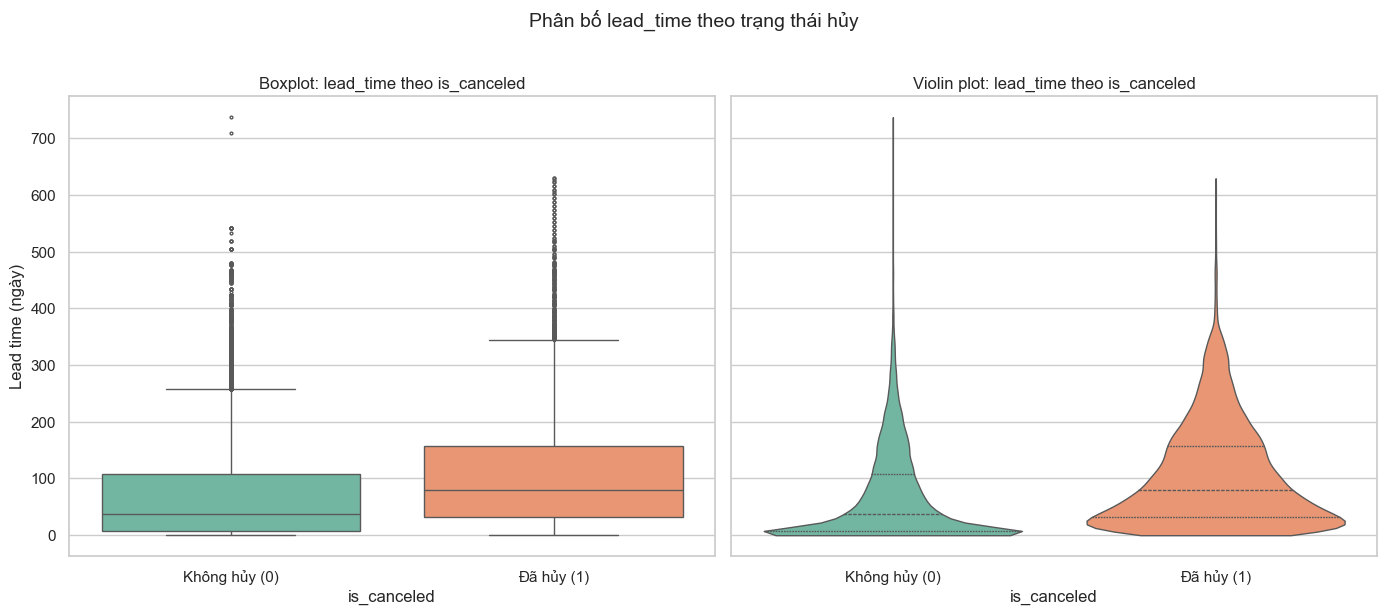

=== Thống kê lead_time theo is_canceled ===


,count,mean,median,std,min,max
is_canceled,,,,,,
0,59527,68.18,37.0,79.10,0,737
1,23284,104.86,79.0,91.26,0,629


In [6]:
# --- Biểu đồ 4: Boxplot + Violin plot — X = is_canceled, Y = lead_time ---
status_labels = {0: "Không hủy (0)", 1: "Đã hủy (1)"}
palette = {"Không hủy (0)": "#66c2a5", "Đã hủy (1)": "#fc8d62"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Boxplot
sns.boxplot(
    data=df,
    x="cancel_status",
    y="lead_time",
    order=[status_labels[0], status_labels[1]],
    palette=palette,
    ax=axes[0],
    linewidth=1,
    fliersize=2,
)
axes[0].set_title("Boxplot: lead_time theo is_canceled")
axes[0].set_xlabel("is_canceled")
axes[0].set_ylabel("Lead time (ngày)")

# Violin plot
sns.violinplot(
    data=df,
    x="cancel_status",
    y="lead_time",
    order=[status_labels[0], status_labels[1]],
    palette=palette,
    ax=axes[1],
    inner="quartile",
    linewidth=1,
    cut=0,
)
axes[1].set_title("Violin plot: lead_time theo is_canceled")
axes[1].set_xlabel("is_canceled")
axes[1].set_ylabel("")

fig.suptitle("Phân bố lead_time theo trạng thái hủy", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Thống kê tóm tắt
print("=== Thống kê lead_time theo is_canceled ===")
display(
    df.groupby("is_canceled")["lead_time"]
    .agg(count="count", mean="mean", median="median", std="std", min="min", max="max")
    .round(2)
)

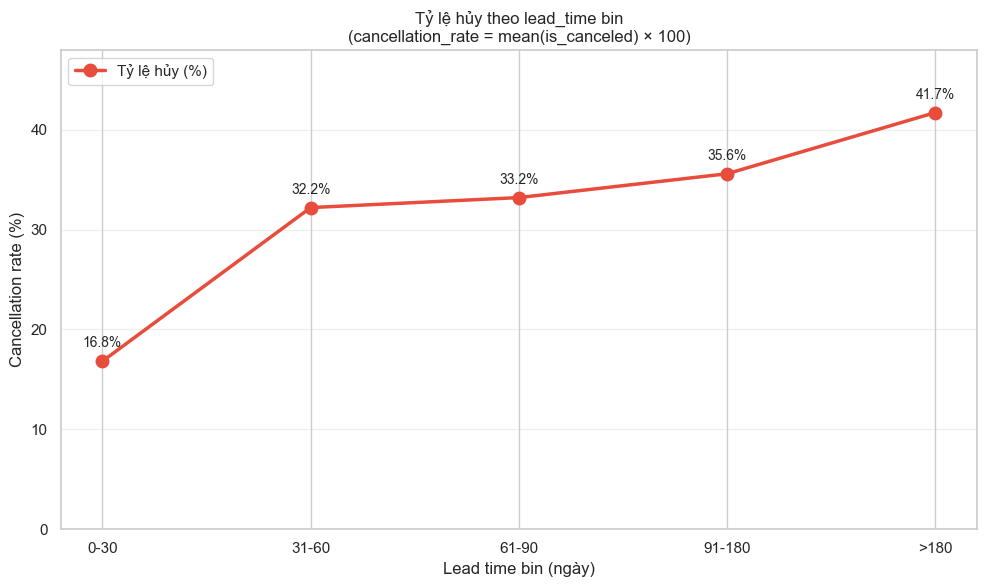

=== Bảng tỷ lệ hủy theo bin ===


,lead_time_bin,bookings,canceled,cancellation_rate
0,0-30,33039,5559,16.83
1,31-60,12776,4115,32.21
2,61-90,8967,2978,33.21
3,91-180,17355,6178,35.60
4,>180,10674,4454,41.73


In [7]:
# --- Biểu đồ 5: Line chart tỷ lệ hủy theo lead_time bin ---
# cancellation_rate = mean(is_canceled) trong từng bin
rate_df = cancel_rate.reset_index()
rate_df["cancellation_rate"] = rate_df["cancel_rate_pct"]  # đã = mean(is_canceled) * 100

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    rate_df["lead_time_bin"].astype(str),
    rate_df["cancellation_rate"],
    marker="o",
    markersize=9,
    linewidth=2.5,
    color="#e74c3c",
    label="Tỷ lệ hủy (%)",
)

# Ghi nhãn % trên từng điểm
for _, row in rate_df.iterrows():
    ax.annotate(
        f"{row['cancellation_rate']:.1f}%",
        (str(row["lead_time_bin"]), row["cancellation_rate"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=10,
    )

ax.set_xticks(range(len(BIN_LABELS)))
ax.set_xticklabels(BIN_LABELS)
ax.set_xlabel("Lead time bin (ngày)")
ax.set_ylabel("Cancellation rate (%)")
ax.set_title("Tỷ lệ hủy theo lead_time bin\n(cancellation_rate = mean(is_canceled) × 100)")
ax.set_ylim(0, rate_df["cancellation_rate"].max() * 1.15)
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

print("=== Bảng tỷ lệ hủy theo bin ===")
display(rate_df[["lead_time_bin", "bookings", "canceled", "cancellation_rate"]].round(2))

## Phân tích cancellation theo ``deposit_type``

=== Thống kê cancellation theo deposit_type ===


,bookings,canceled,cancellation_rate
deposit_type,,,
No Deposit,81767,22346,27.33
Refundable,81,23,28.40
Non Refund,963,915,95.02


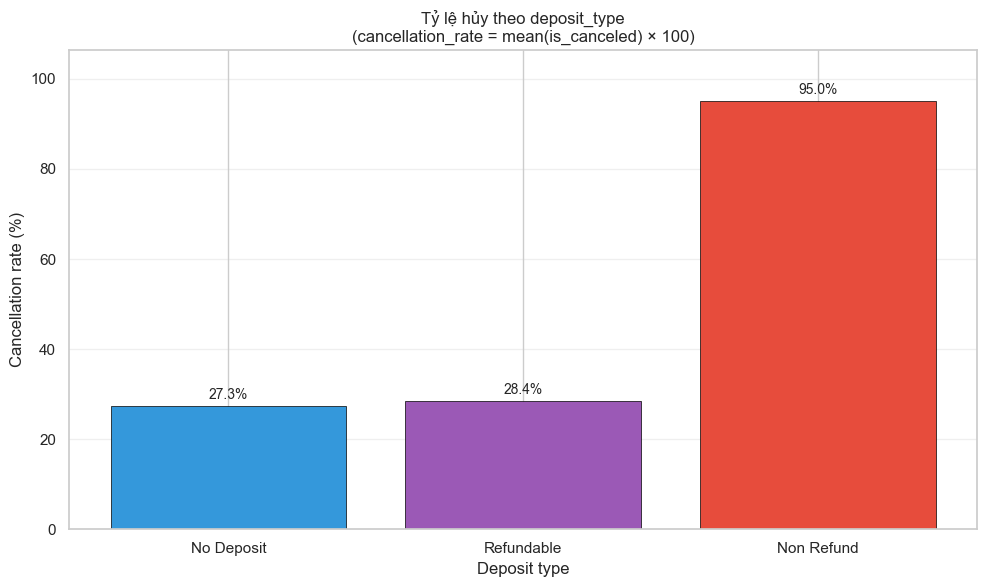

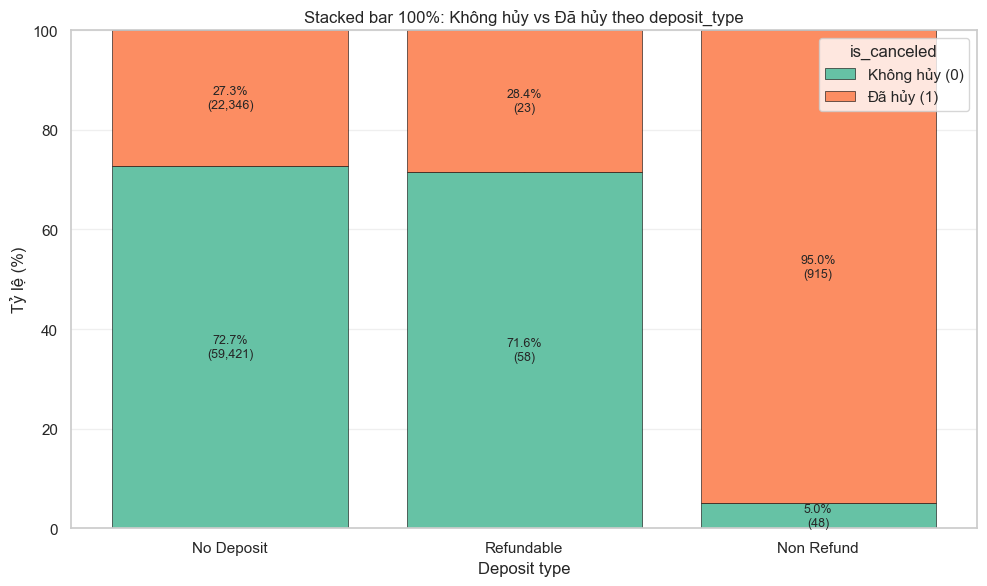

In [8]:
# --- Phân tích cancellation theo deposit_type ---
DEPOSIT_ORDER = ["No Deposit", "Refundable", "Non Refund"]

df["cancel_status"] = df["is_canceled"].map({0: "Không hủy (0)", 1: "Đã hủy (1)"})

deposit_stats = (
    df.groupby("deposit_type", observed=True)["is_canceled"]
    .agg(
        bookings="count",
        canceled="sum",
        cancellation_rate=lambda x: x.mean() * 100,
    )
    .reindex(DEPOSIT_ORDER)
)

print("=== Thống kê cancellation theo deposit_type ===")
display(deposit_stats.round(2))

rate_df = deposit_stats.reset_index()

count_table = (
    df.groupby(["deposit_type", "cancel_status"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(DEPOSIT_ORDER)
)

pct_table = count_table.div(count_table.sum(axis=1), axis=0) * 100

# Biểu đồ 6: Bar chart tỷ lệ hủy (%)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    rate_df["deposit_type"],
    rate_df["cancellation_rate"],
    color=["#3498db", "#9b59b6", "#e74c3c"],
    edgecolor="black",
    linewidth=0.5,
)

for bar, val in zip(bars, rate_df["cancellation_rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_xlabel("Deposit type")
ax.set_ylabel("Cancellation rate (%)")
ax.set_title(
    "Tỷ lệ hủy theo deposit_type\n"
    "(cancellation_rate = mean(is_canceled) × 100)"
)
ax.set_ylim(0, rate_df["cancellation_rate"].max() * 1.12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Biểu đồ 7: Stacked bar 100% (Không hủy vs Đã hủy)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#66c2a5", "#fc8d62"]
labels = ["Không hủy (0)", "Đã hủy (1)"]
bottom = np.zeros(len(DEPOSIT_ORDER))

for i, col in enumerate(labels):
    if col not in count_table.columns:
        continue

    pct_vals = pct_table[col].values
    cnt_vals = count_table[col].values

    ax.bar(
        DEPOSIT_ORDER,
        pct_vals,
        bottom=bottom,
        label=col,
        color=colors[i],
        edgecolor="black",
        linewidth=0.4,
    )

    for j, (pct, cnt) in enumerate(zip(pct_vals, cnt_vals)):
        if pct > 3:
            ax.text(
                j,
                bottom[j] + pct / 2,
                f"{pct:.1f}%\n({cnt:,})",
                ha="center",
                va="center",
                fontsize=9,
            )

    bottom += pct_vals

ax.set_xlabel("Deposit type")
ax.set_ylabel("Tỷ lệ (%)")
ax.set_title("Stacked bar 100%: Không hủy vs Đã hủy theo deposit_type")
ax.set_ylim(0, 100)
ax.legend(title="is_canceled", loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Phân tích cancellation theo ``market_segment``

=== Thống kê cancellation theo market_segment ===


,bookings,canceled,cancellation_rate
market_segment,,,
Undefined,2,2,100.00
Online TA,50391,17906,35.53
Groups,3690,1151,31.19
Aviation,220,42,19.09
Offline TA/TO,12860,1937,15.06
Direct,11351,1693,14.91
Complementary,619,81,13.09
Corporate,3678,472,12.83


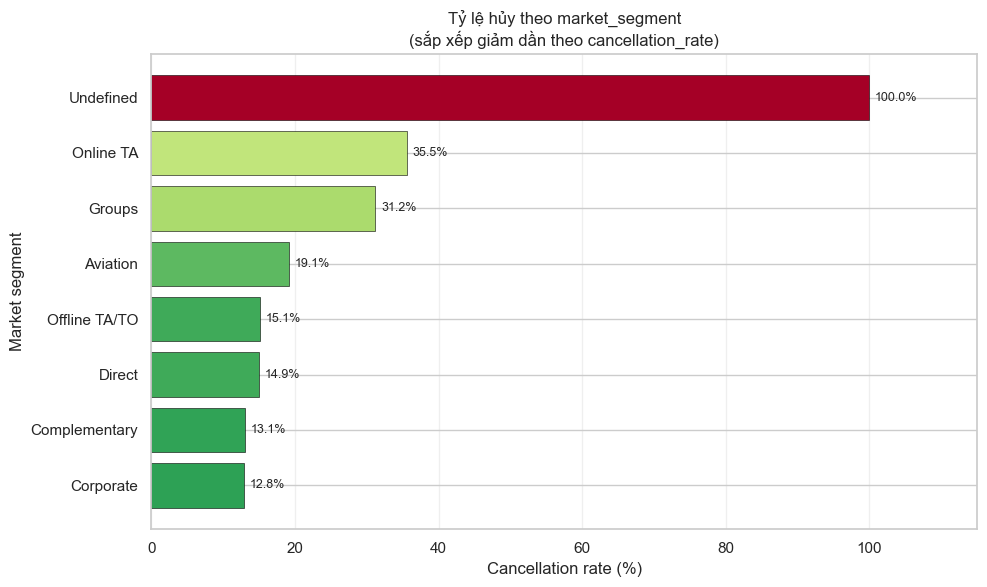

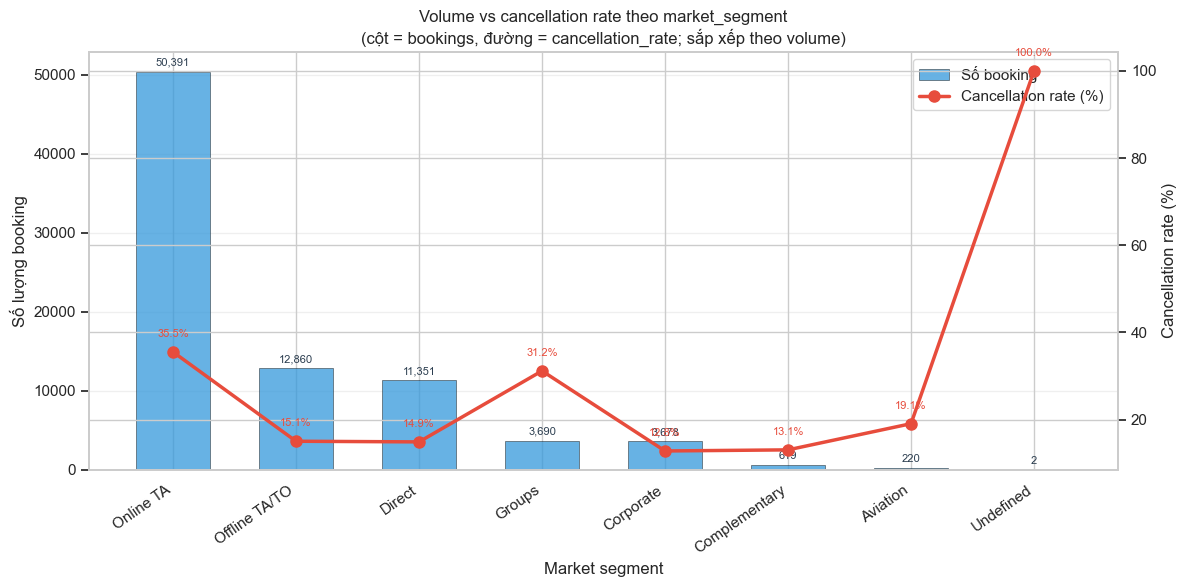

In [9]:
# --- Phân tích cancellation theo market_segment ---
segment_stats = (
    df.groupby("market_segment", observed=True)["is_canceled"]
    .agg(
        bookings="count",
        canceled="sum",
        cancellation_rate=lambda x: x.mean() * 100,
    )
    .sort_values("cancellation_rate", ascending=False)
)

print("=== Thống kê cancellation theo market_segment ===")
display(segment_stats.round(2))

rate_sorted = segment_stats.sort_values("cancellation_rate", ascending=True)
volume_sorted = segment_stats.sort_values("bookings", ascending=False)

# Biểu đồ 8: Horizontal bar — tỷ lệ hủy, sắp xếp giảm dần (cao nhất ở trên)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    rate_sorted.index,
    rate_sorted["cancellation_rate"],
    color=plt.cm.RdYlGn_r(
        rate_sorted["cancellation_rate"] / rate_sorted["cancellation_rate"].max()
    ),
    edgecolor="black",
    linewidth=0.4,
)

for bar, val in zip(bars, rate_sorted["cancellation_rate"]):
    ax.text(
        val + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=9,
    )

ax.set_xlabel("Cancellation rate (%)")
ax.set_ylabel("Market segment")
ax.set_title(
    "Tỷ lệ hủy theo market_segment\n"
    "(sắp xếp giảm dần theo cancellation_rate)"
)
ax.set_xlim(0, rate_sorted["cancellation_rate"].max() * 1.15)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Biểu đồ 9: Dual-axis — cột = volume, đường = cancellation_rate
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(volume_sorted))
bar_width = 0.6

bars = ax.bar(
    x,
    volume_sorted["bookings"],
    width=bar_width,
    color="#3498db",
    alpha=0.75,
    edgecolor="black",
    linewidth=0.4,
    label="Số booking",
)

ax_rate = ax.twinx()
line = ax_rate.plot(
    x,
    volume_sorted["cancellation_rate"],
    color="#e74c3c",
    marker="o",
    markersize=8,
    linewidth=2.5,
    label="Cancellation rate (%)",
)

for xi, (cnt, rate) in enumerate(
    zip(volume_sorted["bookings"], volume_sorted["cancellation_rate"])
):
    ax.text(
        xi,
        cnt + volume_sorted["bookings"].max() * 0.01,
        f"{cnt:,}",
        ha="center",
        va="bottom",
        fontsize=8,
        color="#2c3e50",
    )
    ax_rate.text(
        xi,
        rate + volume_sorted["cancellation_rate"].max() * 0.03,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        color="#e74c3c",
    )

ax.set_xticks(x)
ax.set_xticklabels(volume_sorted.index, rotation=35, ha="right")
ax.set_xlabel("Market segment")
ax.set_ylabel("Số lượng booking")
ax_rate.set_ylabel("Cancellation rate (%)")
ax.set_title(
    "Volume vs cancellation rate theo market_segment\n"
    "(cột = bookings, đường = cancellation_rate; sắp xếp theo volume)"
)
ax.grid(axis="y", alpha=0.3)

lines = [bars] + line
legend_labels = [l.get_label() for l in lines]
ax.legend(lines, legend_labels, loc="upper right")
plt.tight_layout()
plt.show()


## Phân tích cancellation theo distribution_channel

=== Thống kê cancellation theo distribution_channel ===


,bookings,canceled,cancellation_rate
distribution_channel,,,
Corporate,4387,597,13.61
Direct,12291,1853,15.08
GDS,172,34,19.77
TA/TO,65956,20796,31.53
Undefined,5,4,80.00


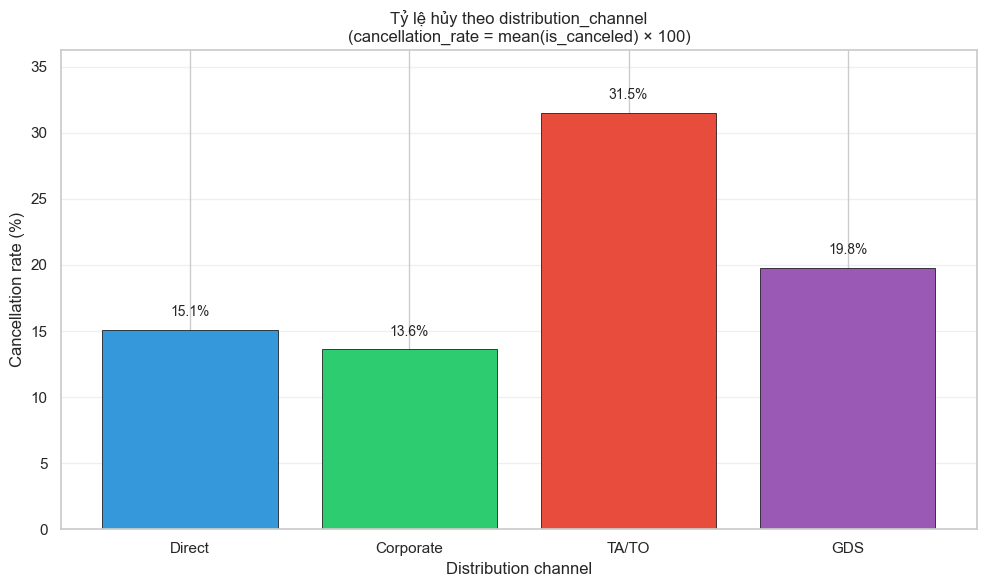

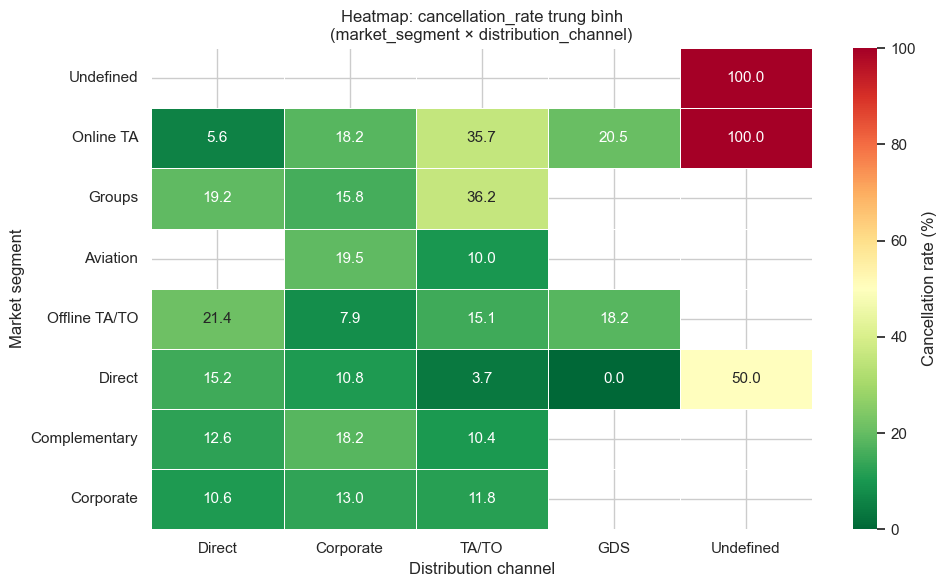

In [10]:
# --- Phân tích cancellation theo distribution_channel ---
CHANNEL_ORDER = ["Direct", "Corporate", "TA/TO", "GDS"]

channel_stats = (
    df.groupby("distribution_channel", observed=True)["is_canceled"]
    .agg(
        bookings="count",
        canceled="sum",
        cancellation_rate=lambda x: x.mean() * 100,
    )
)

print("=== Thống kê cancellation theo distribution_channel ===")
display(channel_stats.round(2))

rate_df = channel_stats.reindex(CHANNEL_ORDER)

segment_order = (
    df.groupby("market_segment", observed=True)["is_canceled"]
    .mean()
    .sort_values(ascending=False)
    .index
)

heat_channels = CHANNEL_ORDER + [
    c for c in channel_stats.index if c not in CHANNEL_ORDER
]

heat_df = (
    df.groupby(["market_segment", "distribution_channel"], observed=True)["is_canceled"]
    .mean()
    .mul(100)
    .unstack(fill_value=np.nan)
    .reindex(index=segment_order, columns=heat_channels)
)

# Biểu đồ 10: Bar chart tỷ lệ hủy theo distribution_channel
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    rate_df.index.astype(str),
    rate_df["cancellation_rate"],
    color=["#3498db", "#2ecc71", "#e74c3c", "#9b59b6"],
    edgecolor="black",
    linewidth=0.5,
)

for bar, val in zip(bars, rate_df["cancellation_rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_xlabel("Distribution channel")
ax.set_ylabel("Cancellation rate (%)")
ax.set_title(
    "Tỷ lệ hủy theo distribution_channel\n"
    "(cancellation_rate = mean(is_canceled) × 100)"
)
ax.set_ylim(0, rate_df["cancellation_rate"].max() * 1.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Biểu đồ 11: Heatmap market_segment × distribution_channel
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    heat_df,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Cancellation rate (%)"},
    ax=ax,
)

ax.set_xlabel("Distribution channel")
ax.set_ylabel("Market segment")
ax.set_title(
    "Heatmap: cancellation_rate trung bình\n"
    "(market_segment × distribution_channel)"
)
plt.tight_layout()
plt.show()
